We apply several methods to the mouse embryonic brain dataset.

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import scvelo as scv
import torch
from velovi import preprocess_data, VELOVI

import seaborn as sns
import matplotlib.pyplot as plt

/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:549: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/mnt/sw/nix/store/5zccdpbxzjvkky2asjixbxz4g7kgg4lh-python-3.9.18-view/lib/python3.9/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'n

In [2]:
# !python -m pip install scvi-colab
# from scvi_colab import install
# install()

In [7]:
#filtering, normalization and moments were already applied
data_outdir = 'processed_data/'
adata_rna = sc.read_h5ad(data_outdir+'adata_rna.h5ad')

In [8]:
model_outdir = 'modeling_results/10_comps/'

## Apply VeloVI

Apply standard veloVI pipeline.

In [10]:
adata_rna = preprocess_data(adata_rna)

computing velocities
    finished (0:00:00) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [8]:
VELOVI.setup_anndata(adata_rna , spliced_layer="Ms", unspliced_layer="Mu")

In [ ]:
vae = VELOVI(adata_rna )
vae.train()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Epoch 2/500:   0%|          | 1/500 [00:12<1:43:37, 12.46s/it, v_num=1, train_loss_step=-113, train_loss_epoch=279]

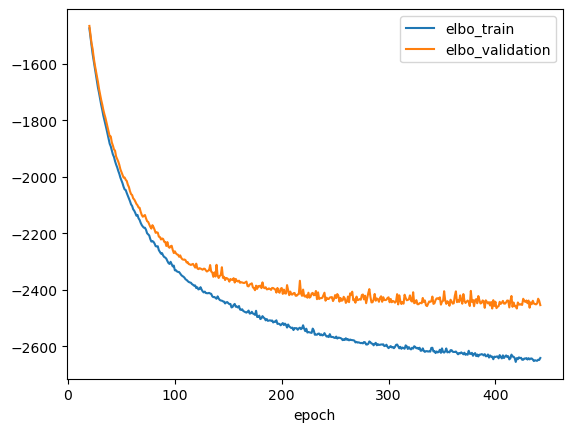

In [11]:
fig, ax = plt.subplots()
vae.history["elbo_train"].iloc[20:].plot(ax=ax, label="train")
vae.history["elbo_validation"].iloc[20:].plot(ax=ax, label="validation")
plt.legend()

In [ ]:
import pickle
f = open(model_outdir+'vae.p', 'wb')
pickle.dump(vae, f)
f.close()

In [9]:
import pickle
f = open(model_outdir+'vae.p', 'rb')
vae = pickle.load(f)
f.close()

In [10]:
# save outputs
def add_velovi_outputs_to_adata(adata, vae):
    latent_time = vae.get_latent_time(n_samples=25)
    velocities = vae.get_velocity(n_samples=25, velo_statistic="mean")

    t = latent_time
    scaling = 20 / t.max(0)

    adata.layers["velocity"] = velocities / scaling
    adata.layers["latent_time_velovi"] = latent_time

    adata.var["fit_alpha"] = vae.get_rates()["alpha"] / scaling
    adata.var["fit_beta"] = vae.get_rates()["beta"] / scaling
    adata.var["fit_gamma"] = vae.get_rates()["gamma"] / scaling
    adata.var["fit_t_"] = (
        torch.nn.functional.softplus(vae.module.switch_time_unconstr)
        .detach()
        .cpu()
        .numpy()
    ) * scaling
    adata.layers["fit_t"] = latent_time.values * scaling.values[np.newaxis, :]
    adata.var['fit_scaling'] = 1.0

add_velovi_outputs_to_adata(adata_rna, vae)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             



KeyboardInterrupt



In [ ]:
scv.tl.velocity_graph(adata_rna)

In [ ]:
scv.pl.velocity_embedding_stream(adata_rna, basis='umap')

In [24]:
adata_rna.write(model_outdir+'VeloVI_result.h5ad')


In [94]:
# save s and u fits for later likelihood comparison
s_fits, u_fits = vae.get_expression_fit(n_samples = 20)

In [95]:
s_fits.to_csv(model_outdir+'VeloVI_s_fits.csv')
u_fits.to_csv(model_outdir+'VeloVI_u_fits.csv')